In [35]:
import deepxde as dde
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# pde setup
from pde_geom import *
from net import *

In [4]:
# should match openfoam mesh
x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
nx, ny = 60, 40

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny)

X_grid, Y_grid = np.meshgrid(x_centers, y_centers)
coordinates_precice = np.vstack([X_grid.flatten(), Y_grid.flatten()]).T

In [32]:
def magnitude(vector_field):
    reshaped = vector_field.reshape((ny, nx, 2))
    x = reshaped[:, :, 0]
    y = reshaped[:, :, 1]
    return np.sqrt(x**2 + y**2)

In [9]:
data = np.load('training_data.npz')
X_train = data['X_train']
Y_train = data['Y_train']

# Define model

In [11]:
unsupervised_loss_terms

In [12]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

1678

In [13]:
supervised_loss = dde.icbc.PointSetBC(X_train, Y_train)
loss_terms = unsupervised_loss_terms + [supervised_loss]
loss_weights = unsupervised_loss_weights + [10000000.0]

data = dde.data.TimePDE(
    geom,
    navier_stokes_pde,
    loss_terms,
    num_domain=num_domain_points,
    num_boundary=num_boundary_points,
    num_initial=num_initial_points,
    num_test=num_test_points
)

model = dde.Model(data, net)

lr = 1e-4
model.compile(
    "adam",
    lr=lr,
    loss_weights=loss_weights
)

# # Load  trained model
# model_path = "navier_stokes_channel_obstacle_model-600.pt"

# if not os.path.exists(model_path):
#     print(f"Error: Model file {model_path} not found!")
#     sys.exit(1)
# model.restore(save_path=model_path, verbose=1)

Compiling model...
'compile' took 0.973865 s



In [14]:
def model_predict(x_mesh, y_mesh, time=0.0):
    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time)
    
    # Input to model: (x, y, t)
    points_to_predict = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    
    # Model predicts (u, v, p)
    predictions = model.predict(points_to_predict)
    
    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()
    
    return Velocity, Pressure

Velocity, Pressure = model_predict(X_grid, Y_grid, time=0.0)

In [15]:
# checkpoint_callback = dde.callbacks.ModelCheckpoint(
#     os.path.join(training_output_dir, f"{model_base_name}"),
#     save_better_only=True,
#     period=50
# )

iterations = 1000

losshistory, train_state = model.train(
    iterations=iterations,
    display_every=100
    # callbacks=[checkpoint_callback]
)

Training model...

Step      Train loss                                                                                                                                                          Test loss                                                                                                                                                           Test metric
0         [2.94e-02, 8.45e-02, 1.06e-01, 2.89e+00, 3.52e-01, 3.85e-01, 2.40e+02, 1.15e-02, 3.21e-02, 7.48e+01, 1.01e-03, 2.58e-02, 3.58e-01, 1.45e-01, 1.17e+00, 3.32e+06]    [2.14e-02, 4.97e-02, 9.48e-02, 2.89e+00, 3.52e-01, 3.85e-01, 2.40e+02, 1.15e-02, 3.21e-02, 7.48e+01, 1.01e-03, 2.58e-02, 3.58e-01, 1.45e-01, 1.17e+00, 3.32e+06]    []  
100       [1.27e-01, 2.41e-02, 7.80e-02, 2.03e+00, 6.53e-01, 1.38e-01, 2.02e+02, 5.10e-02, 2.65e-02, 4.76e+01, 1.58e-02, 2.28e-02, 4.22e-01, 7.79e-01, 1.11e+00, 1.91e+06]    [1.08e-01, 2.12e-02, 6.47e-02, 2.03e+00, 6.53e-01, 1.38e-01, 2.02e+02, 5.10e-02, 2.65e-02, 4.76e+01, 1.58e-02, 2.2

In [23]:
model_path = os.path.join(training_output_dir, f"{model_base_name}")
os.mkdir(training_output_dir) if not os.path.exists(training_output_dir) else None
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: train_dir/ns_obstacle


Saving loss history to train_dir/loss.dat ...
Saving training data to train_dir/train.dat ...
Saving test data to train_dir/test.dat ...


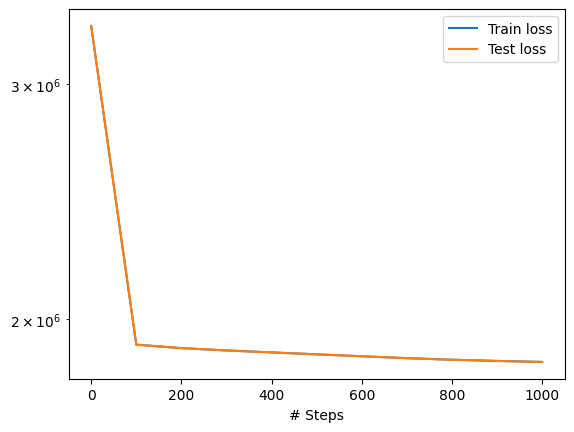

In [24]:
dde.saveplot(
    losshistory, 
    train_state, 
    issave=True, 
    isplot=True,
    output_dir=training_output_dir
)

In [37]:
def update_plot(ax, field_data, time_value, field_name, vmin=None, vmax=None, cmap='coolwarm'):
    ax.clear()
    field_reshaped = field_data.reshape(ny, nx)
    
    im = ax.imshow(field_reshaped, cmap=cmap, origin='lower', 
                   extent=(x_min, x_max, y_min, y_max),
                   vmin=vmin, vmax=vmax)
    
    # Add obstacle
    ax.add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                              obstacle_x1-obstacle_x0, 
                              obstacle_y1-obstacle_y0,
                              color='white', alpha=0.7))
    
    ax.set_title(f'{field_name} at t = {time_value:.2f}s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    return [im]

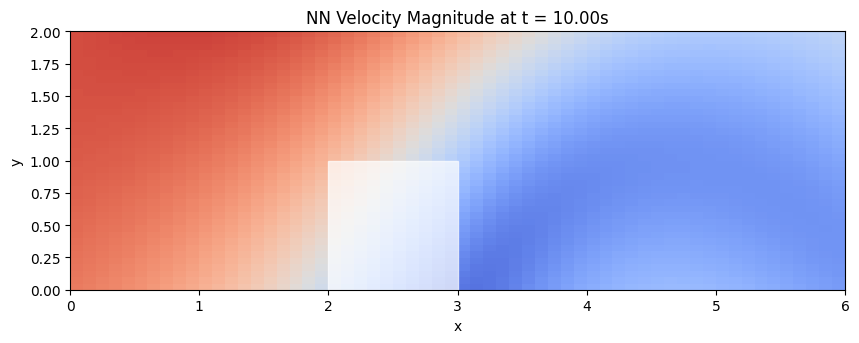

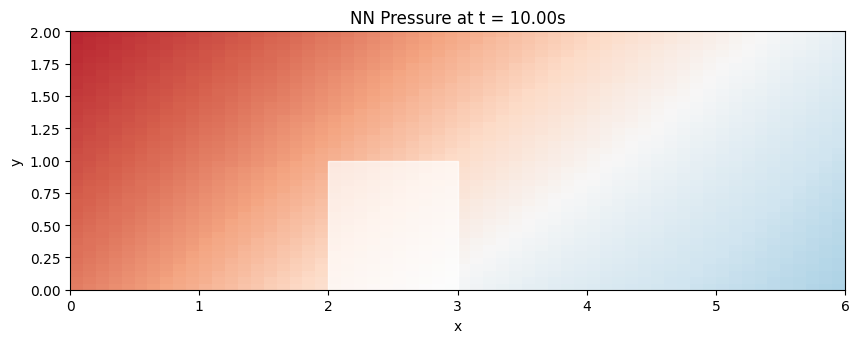

In [39]:
# Neural network predictions (0 to 10 seconds at 20fps)
time_points = np.linspace(0, 10, 200)
nn_vel_mags = []
nn_pressures = []

for t in time_points:
    vel, press = model_predict(X_grid, Y_grid, time=t)
    nn_vel_mags.append(magnitude(vel).flatten())
    nn_pressures.append(press)

# NN velocity animation
fig_nn_vel, ax_nn_vel = plt.subplots(figsize=(10, 6))
nn_v_min, nn_v_max = np.min(nn_vel_mags), np.max(nn_vel_mags)

def animate_nn_velocity(frame):
    return update_plot(ax_nn_vel, nn_vel_mags[frame], time_points[frame],
                      'NN Velocity Magnitude', vmin=nn_v_min, vmax=nn_v_max)

ani_nn_vel = FuncAnimation(fig_nn_vel, animate_nn_velocity, frames=len(time_points), blit=True)
ani_nn_vel.save('nn_velocity_animation.mp4', writer='ffmpeg', fps=20)

# NN pressure animation
fig_nn_press, ax_nn_press = plt.subplots(figsize=(10, 6))
nn_p_min, nn_p_max = np.min(nn_pressures), np.max(nn_pressures)

def animate_nn_pressure(frame):
    return update_plot(ax_nn_press, nn_pressures[frame], time_points[frame],
                      'NN Pressure', vmin=nn_p_min, vmax=nn_p_max, cmap='RdBu_r')

ani_nn_press = FuncAnimation(fig_nn_press, animate_nn_pressure, frames=len(time_points), blit=True)
ani_nn_press.save('nn_pressure_animation.mp4', writer='ffmpeg', fps=20)

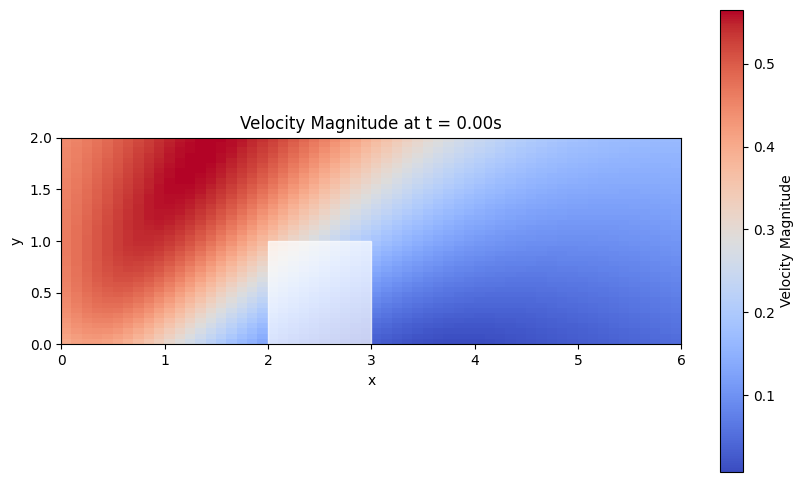

In [41]:
Velocity, Pressure = model_predict(X_grid, Y_grid, time=0.0)

velocity_magnitude = magnitude(Velocity)
plt.figure(figsize=(10, 6))

velocity_magnitude_reshaped = velocity_magnitude.reshape(ny, nx)
im = plt.imshow(velocity_magnitude_reshaped, cmap='coolwarm', origin='lower', 
               extent=(x_min, x_max, y_min, y_max))

plt.gca().add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                                 obstacle_x1-obstacle_x0, 
                                 obstacle_y1-obstacle_y0,
                                 color='white', alpha=0.7))

plt.colorbar(label='Velocity Magnitude')
plt.title('Velocity Magnitude at t = 0.00s')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(os.path.join(training_output_dir, 'velocity_magnitude.png'))
plt.show()

In [46]:
!jupyter nbconvert --to script 'training-participant.ipynb'

[NbConvertApp] Converting notebook training-participant.ipynb to script
[NbConvertApp] Writing 6177 bytes to training-participant.py


In [51]:
Y_train.shape

(65536, 3)

ValueError: cannot reshape array of size 1472 into shape (40,60,2)

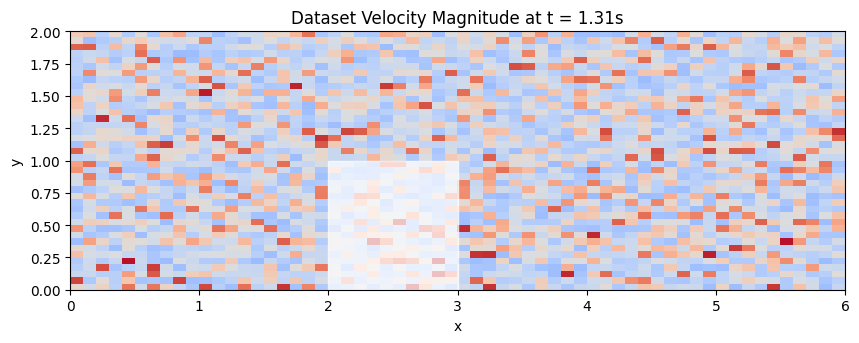

In [53]:
t = X_train[:, 2]  # Extract time values from training data
# sort indices based on time
sorted_indices = np.argsort(t)
X_train = X_train[sorted_indices]
Y_train = Y_train[sorted_indices]

# Dataset velocity animation
fig_data_vel, ax_data_vel = plt.subplots(figsize=(10, 6))
data_v_min, data_v_max = np.min(Y_train[:, :2]), np.max(Y_train[:, :2])

def animate_data_velocity(frame):
    vel = magnitude(Y_train[frame * nx * ny:(frame + 1) * nx * ny, :2])
    return update_plot(ax_data_vel, vel.flatten(), time_points[frame],
                       'Dataset Velocity Magnitude', vmin=data_v_min, vmax=data_v_max)

ani_data_vel = FuncAnimation(fig_data_vel, animate_data_velocity, frames=len(time_points), blit=True)
ani_data_vel.save('dataset_velocity_animation.mp4', writer='ffmpeg', fps=20)

# Dataset pressure animation
fig_data_press, ax_data_press = plt.subplots(figsize=(10, 6))
data_p_min, data_p_max = np.min(Y_train[:, 2]), np.max(Y_train[:, 2])

def animate_data_pressure(frame):
    press = Y_train[frame * nx * ny:(frame + 1) * nx * ny, 2].reshape(ny, nx)
    return update_plot(ax_data_press, press.flatten(), time_points[frame],
                       'Dataset Pressure', vmin=data_p_min, vmax=data_p_max, cmap='RdBu_r')

ani_data_press = FuncAnimation(fig_data_press, animate_data_pressure, frames=len(time_points), blit=True)
ani_data_press.save('dataset_pressure_animation.mp4', writer='ffmpeg', fps=20)